In [161]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [162]:
# Load train.csv into notebook for analysis
train_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [163]:
#Load test.csv into notebook for analysis
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
test_data.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [164]:
#Check percentage of women who survived to 2 decimal places (verification for gender_submission.csv)

women = train_data.loc[train_data.Sex == 'female']['Survived']
rate_women = (sum(women)/len(women))*100

print('percentage of women who survived:', f'{rate_women:.2f}'+'%')

percentage of women who survived: 74.20%


In [165]:
#Check percentage of men who survived to 2 decimal places (verfication for gender_submission.csv)
men = train_data.loc[train_data.Sex == 'male']['Survived']
rate_men = (sum(men)/len(men))*100

print('percentage of men who survived:', f'{rate_men:.2f}'+'%')

percentage of men who survived: 18.89%


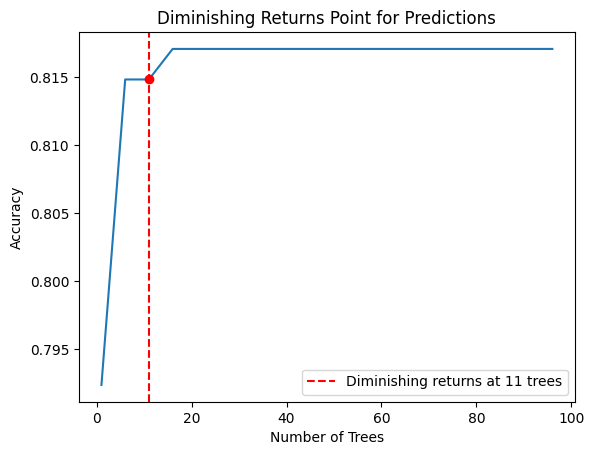

Diminishing point at 11
Accuracy at that point is 0.8148148148148148


In [166]:
# import needed libraries for use
from sklearn.ensemble import RandomForestClassifier  #for random forest tree generation
from sklearn.metrics import accuracy_score           #for accuracy classification

features = ["Sex","Parch","Pclass","SibSp"]  #features of the random forest tree

x = pd.get_dummies(train_data[features])  #convert columns to numbers
x_test = pd.get_dummies(test_data[features])  #convert columns to numbers

y = train_data["Survived"]  #target

estimator_range = range(1, 100, 5)   #start from 1, count up to 500, in intervals of 5
accuracies = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=5)
    model.fit(x,y)
    prediction = model.predict(x)
    accuracies.append(accuracy_score(y, prediction))

threshold = 0.001
diminishing_point = None
for i in range(1, len(accuracies)):
    if abs(accuracies[i] - accuracies[i-1]) < threshold:
        diminishing_point = list(estimator_range)[i]
        break

plt.plot(estimator_range, accuracies)
plt.axvline(x=diminishing_point, color='red', linestyle='--', label=f'Diminishing returns at {diminishing_point} trees')
plt.scatter([diminishing_point], [accuracies[list(estimator_range).index(diminishing_point)]], color='red', zorder=5)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Diminishing Returns Point for Predictions')
plt.legend()
plt.show()

print(f'Diminishing point at {diminishing_point}')
print(f'Accuracy at that point is {accuracies[list(estimator_range).index(diminishing_point)]}')

In [167]:
#model for predictions
model = RandomForestClassifier(n_estimators=11, random_state=5)
model.fit(x,y)
prediction = model.predict(x_test)

#output as a dataframe
output=pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': prediction})
print(output.head())

#output to csv
output.to_csv('TitanicCompSubmission.csv', index=False)
print('Your CSV file has been created!')

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Your CSV file has been created!
